# 上证综指探索性数据分析（EDA）

本 Notebook 对上证综指（sh.000001）收盘价进行系统性的探索性数据分析，
涵盖数据加载、基本统计、价格走势、收益率分布、自相关以及平稳性检验。

In [1]:
%matplotlib inline
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src.data_loader import load_train
from src.preprocess import preprocess
from src.eda import (
    summary_stats, check_stationarity,
    plot_time_series, plot_distribution, plot_acf_pacf, plot_qq
)

FIGURES = ROOT / 'outputs' / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

## 1. 数据加载

通过 `src/data_loader.py` 载入原始训练数据，查看数据形状、列类型和前几行。

In [2]:
raw = load_train()
print(f'Shape: {raw.shape}')
print()
print(raw.dtypes)
raw.head()

Shape: (1218, 9)

date             str
open         float64
high         float64
low          float64
close        float64
volume         int64
amount       float64
code             str
frequency        str
dtype: object


,date,open,high,low,close,volume,amount,code,frequency
0,2016-01-04,3536.589,3538.689,3295.741,3296.258,18441842432,2.409292e+11,sh.000001,d
1,2016-01-05,3196.651,3328.139,3189.605,3287.711,26688208384,3.284172e+11,sh.000001,d
2,2016-01-06,3291.195,3362.974,3288.933,3361.840,23888667136,2.852432e+11,sh.000001,d
3,2016-01-07,3309.657,3309.657,3115.885,3125.002,7056912384,7.998199e+10,sh.000001,d
4,2016-01-08,3194.625,3235.451,3056.878,3186.412,28644082176,3.241671e+11,sh.000001,d


## 2. 基本统计

对收盘价和对数收益率进行描述性统计，并检查缺失值情况。

In [3]:
df = preprocess(raw)
print(f'处理后数据形状: {df.shape}')
print(f'日期范围: {df.index.min().date()} ~ {df.index.max().date()}')
print()
print('缺失值：')
print(df.isnull().sum())

处理后数据形状: (1217, 10)
日期范围: 2016-01-05 ~ 2020-12-31

缺失值：
open          0
high          0
low           0
close         0
volume        0
amount        0
code          0
frequency     0
log_close     0
log_return    0
dtype: int64


In [4]:
print('收盘价描述性统计：')
display(df[['close']].describe())
print()
print('对数收益率描述性统计（含偏度/峰度）：')
display(summary_stats(df['log_return']))

收盘价描述性统计：


,close
count,1217.000000
mean,3048.713752
std,232.486874
min,2464.362000
25%,2890.080000
50%,3052.785000
75%,3242.406000
max,3559.465000



对数收益率描述性统计（含偏度/峰度）：


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
log_return,1217,0.000043,0.011701,-0.080392,-0.004921,0.000579,0.005348,0.055542,-0.990561,7.150293


## 3. 收盘价走势

绘制整个训练期的收盘价时序折线图，观察长期趋势和重大事件影响。

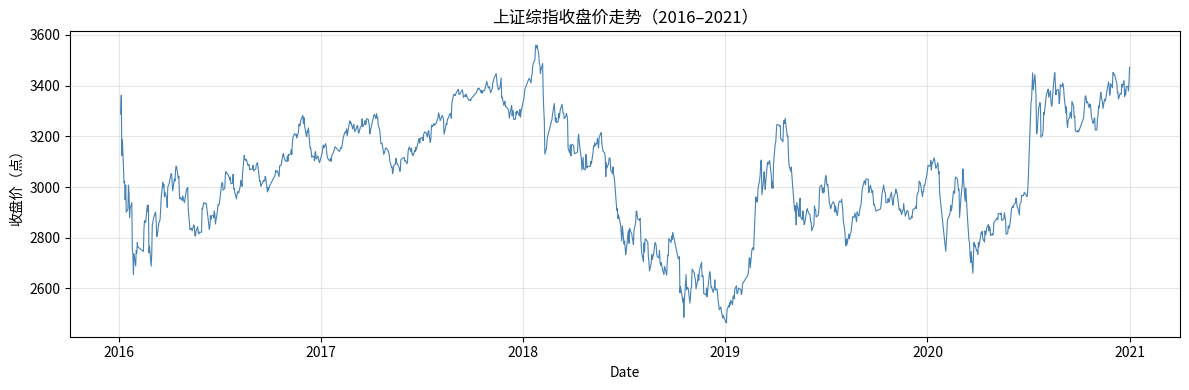

In [5]:
fig = plot_time_series(
    df['close'],
    title='上证综指收盘价走势（2016–2021）',
    ylabel='收盘价（点）',
    save_path=FIGURES / 'eda_close_price.png'
)
plt.show()

## 4. 收益率分布

绘制对数收益率的直方图（含 KDE 和正态拟合）以及 Q-Q 图，
观察收益率分布的厚尾特征和偏度。

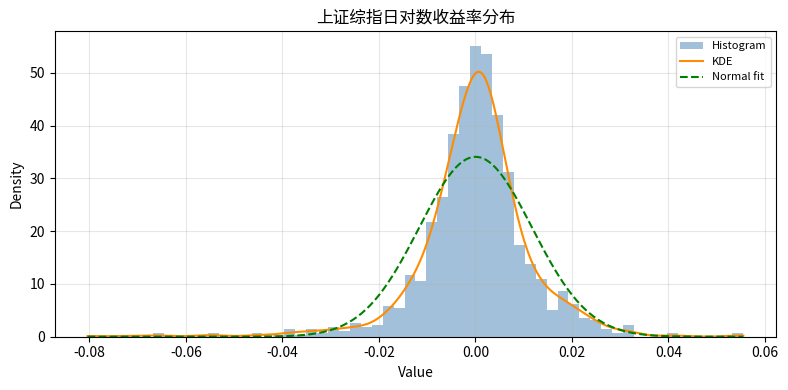

In [6]:
fig = plot_distribution(
    df['log_return'],
    title='上证综指日对数收益率分布',
    save_path=FIGURES / 'eda_return_distribution.png'
)
plt.show()

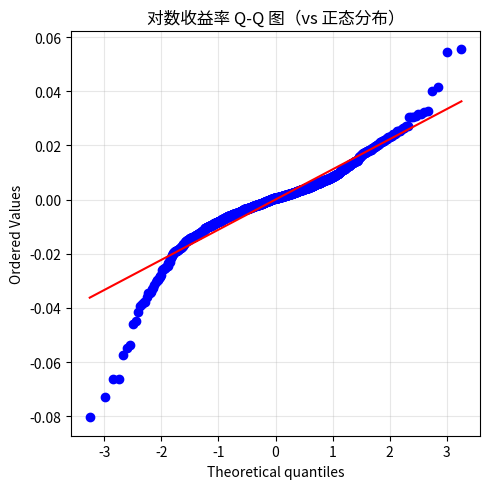

In [7]:
fig = plot_qq(
    df['log_return'],
    title='对数收益率 Q-Q 图（vs 正态分布）',
    save_path=FIGURES / 'eda_return_qq.png'
)
plt.show()

## 5. 自相关分析

分别对收盘价和对数收益率绘制 ACF/PACF 图。
- 收盘价的 ACF 缓慢衰减，说明序列非平稳。
- 收益率的 ACF 快速截尾，基本满足弱相关要求。

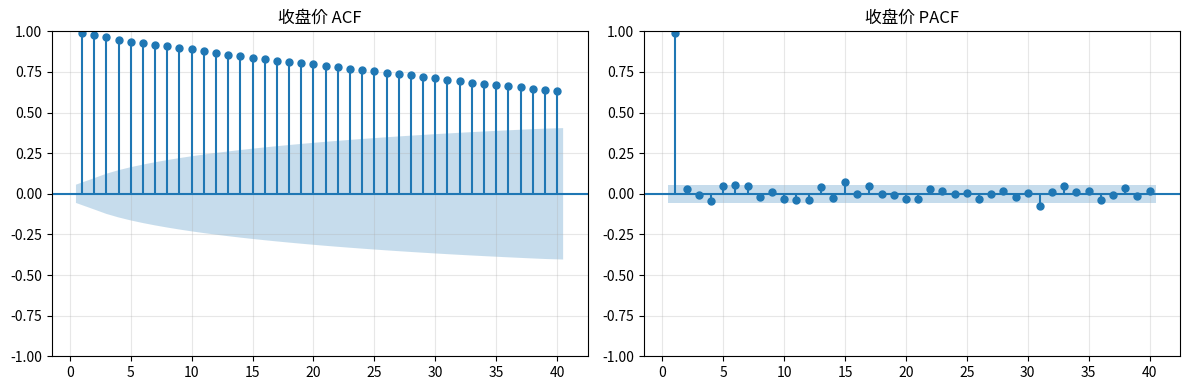

In [8]:
fig = plot_acf_pacf(
    df['close'],
    lags=40,
    title_prefix='收盘价',
    save_path=FIGURES / 'eda_close_acf_pacf.png'
)
plt.show()

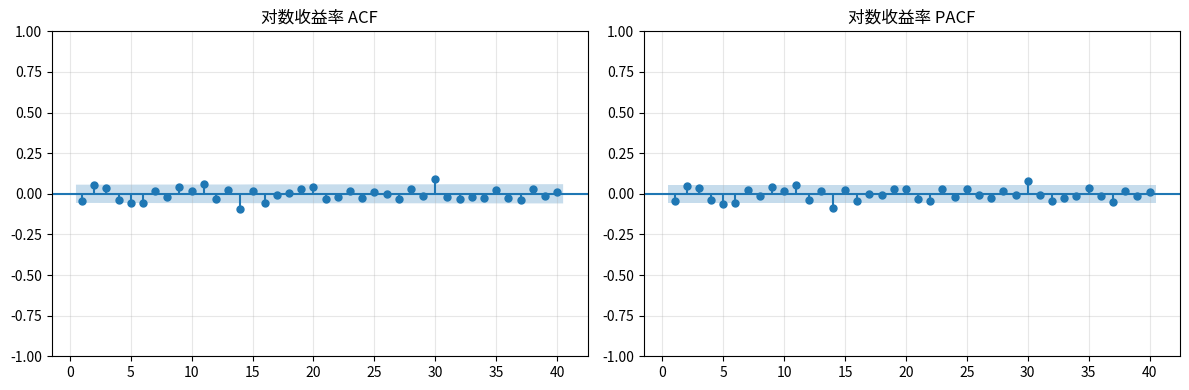

In [9]:
fig = plot_acf_pacf(
    df['log_return'],
    lags=40,
    title_prefix='对数收益率',
    save_path=FIGURES / 'eda_return_acf_pacf.png'
)
plt.show()

## 6. 平稳性检验

使用 ADF（Augmented Dickey-Fuller）检验对收盘价和对数收益率进行平稳性检验，
p < 0.05 则拒绝单位根假设（即序列平稳）。

In [10]:
print('=== 收盘价平稳性检验 ===')
adf_close = check_stationarity(df['close'])
display(adf_close)
if adf_close['is_stationary'].iloc[0]:
    print('✓ 收盘价序列平稳（p < 0.05）')
else:
    print('✗ 收盘价序列非平稳（p >= 0.05）——建议差分后再建模')

=== 收盘价平稳性检验 ===


,adf_statistic,p_value,critical_1%,critical_5%,critical_10%,is_stationary
close,-1.96602,0.301668,-3.435766,-2.863932,-2.568043,False


✗ 收盘价序列非平稳（p >= 0.05）——建议差分后再建模


In [11]:
print('=== 对数收益率平稳性检验 ===')
adf_return = check_stationarity(df['log_return'])
display(adf_return)
if adf_return['is_stationary'].iloc[0]:
    print('✓ 对数收益率序列平稳（p < 0.05）')
else:
    print('✗ 对数收益率序列非平稳（p >= 0.05）')

=== 对数收益率平稳性检验 ===


,adf_statistic,p_value,critical_1%,critical_5%,critical_10%,is_stationary
log_return,-15.992226,6.651586e-29,-3.435761,-2.86393,-2.568042,True


✓ 对数收益率序列平稳（p < 0.05）


## 小结

- **收盘价**：具有明显趋势，ACF 缓慢衰减，ADF 检验不平稳，需要差分或取对数差分处理。
- **对数收益率**：ADF 检验通过平稳性，分布呈现一定的尖峰厚尾特征，适合 GARCH 建模。
- **下一步**：在 `02_arima.ipynb` 中对收盘价进行 ARIMA 建模，在 `03_garch.ipynb` 中对收益率进行 GARCH 建模。